In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln_control import Model_ALN_control
from neurolib.models.aln import ALNModel
from neurolib.models.a import a_Model
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 12
       }

plt.rcParams['axes.grid'] = True

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
    
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.05 ):
            control_[:,:,i_time] = maxI_
    return control_

max delay =  0


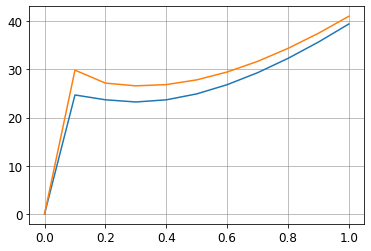

39.42069808669071
41.01903478808262
4.350747861783376
4.490750592866572
0.0
0.0
27.554678439430884
0.0
27.439336647550878
0.0
0.0
0.0
0.0
0.32682912275501874
0.24512184206626408
0.0
0.0
0.039420698086690714
4.942069808669071
5.1019034788082624


In [5]:
aln = a_Model()
setparams()
aln.params['duration'] = 1.

control0 = aln.getZeroControl()
control0 = step_control(maxI_ = 1.)

maxDelay = aln.getMaxDelay()
print("max delay = ", maxDelay)

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars
    
state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    high_state_vars[i] = aln.state[state_vars[i]][0,-1]
    print(high_state_vars[i])

In [6]:
dur_pre = 0.
dur_post = 0.

max_it = 1
tol = 1e-20

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])


In [4]:
def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]
            
def setparams():
    aln.params.mue_ext_mean = 0.
    aln.params.mui_ext_mean = 0.
    aln.params.Jee_max = 1e-26
    aln.params.cee = 0.
    aln.params.Jei_max = 1.
    aln.params.cei = 1.
    aln.params.Jie_max = 1e-26
    aln.params.cie = 0.
    aln.params.Jii_max = 1.
    aln.params.cii = 1.
    
    # NO ADAPTATION
    aln.params.IA_init = np.array([0.])
    aln.params.a = 0.
    aln.params.b = 0.
    
    aln.params.di = 0.0
    aln.params.de = 0.0
    aln.params.signalV = 0.
    
    aln.params.sigmae_ext = 0.
    aln.params.sigmai_ext = 0.

In [7]:
def plot_fig(i):
    lines = 4
    fig, axes = plt.subplots(lines,2, figsize=(18, 12))
    axes[0,i].plot(aln.t, control1[0,0,:], label="control exc")
    axes[0,i+1].plot(aln.t, control1[0,1,:], label="control inh")
    axes[1,i].plot(aln.t, aln.state["rates_exc"][0,:], label="rates exc")
    axes[1,i+1].plot(aln.t, aln.state["rates_inh"][0,:], label="rates inh")
    axes[2,i].plot(aln.t, aln.state["mufe"][0,:], label="mufe")
    axes[2,i+1].plot(aln.t, aln.state["mufi"][0,:], label="mufi")
    #axes[3,i].plot(aln.t, aln.state["IA"][0,:], label="IA")

    #axes[4,i].plot(aln.t, aln.state["seem"][0,:], label="seem")
    axes[3,i].plot(aln.t, aln.state["seim"][0,:], label="seim")
    #axes[5,i+1].plot(aln.t, aln.state["siem"][0,:], label="siem")
    axes[3,i+1].plot(aln.t, aln.state["siim"][0,:], label="siim")

    #axes[4,i].plot(aln.t, aln.state["seev"][0,:], label="seev")
    #axes[4,i+1].plot(aln.t, aln.state["seiv"][0,:], label="seiv")
    #axes[5,i].plot(aln.t, aln.state["siev"][0,:], label="siev")
    #axes[5,i+1].plot(aln.t, aln.state["siiv"][0,:], label="siiv")

    #axes[6,i].plot(aln.t, aln.state["mue_ou"][0,:], label="mue_ou")
    #axes[6,i+1].plot(aln.t, aln.state["mui_ou"][0,:], label="mui_ou")

    #axes[7,i].plot(aln.t, aln.state["sigmae_f"][0,:], label="sigma_e")
    #axes[7,i+1].plot(aln.t, aln.state["sigmai_f"][0,:], label="sigma_i")
    #axes[8,i].plot(aln.t, aln.state["Vmean_exc"][0,:], label="V_mean")
    #axes[9,i].plot(aln.t, aln.state["tau_exc"][0,:], label="tau_exc")
    #axes[9,i+1].plot(aln.t, aln.state["tau_inh"][0,:], label="tau_inh")

    for k in range(lines):
        for j in range(2):
            #if ((k,j) != (3,1) and (k,j) != (8,1)):
            axes[k,j].legend()

    plt.tight_layout()

In [8]:
rates_exc_init = np.array( [[0. ]] )
rates_inh_init = np.array( [[0. ]] )
mufe_init = np.array( [[0. ]] )  # mV/ms
mufi_init = np.array( [[0. ]] )  # mV/ms
IA_init = np.array( [[0. ]] )  # pA
seem_init = np.array( [[0.0 * 0.5 ]] )
seim_init = np.array( [[0.0 * 0.5 ]] )   
seev_init = np.array( [[0.00 * 0.5 ]] )
seiv_init = np.array( [[0.00 * 0.5 ]] )
siim_init = np.array( [[0.0 * 0.5 ]] )
siem_init = np.array( [[0.0 * 0.5 ]] )
siiv_init = np.array( [[0.00 * 0.5 ]] )
siev_init = np.array( [[0.00 * 0.5 ]] )
mue_ou = np.array( [[0. ]] )
mui_ou = np.array( [[0. ]] )

initvars = np.array( [
rates_exc_init,
rates_inh_init,
mufe_init,
mufi_init,
IA_init,
seem_init ,
seim_init,
seev_init,
seiv_init,
siim_init,
siem_init,
siiv_init,
siev_init,
mue_ou,
mui_ou
    ])

[0.     0.     0.     0.     0.     0.1    0.2791 0.518  0.721  0.9123
 1.1173]
[ 0.      0.      1.      0.9091  0.8258 -0.0819  0.1189  0.3774  0.5967
  0.8019  1.0192]


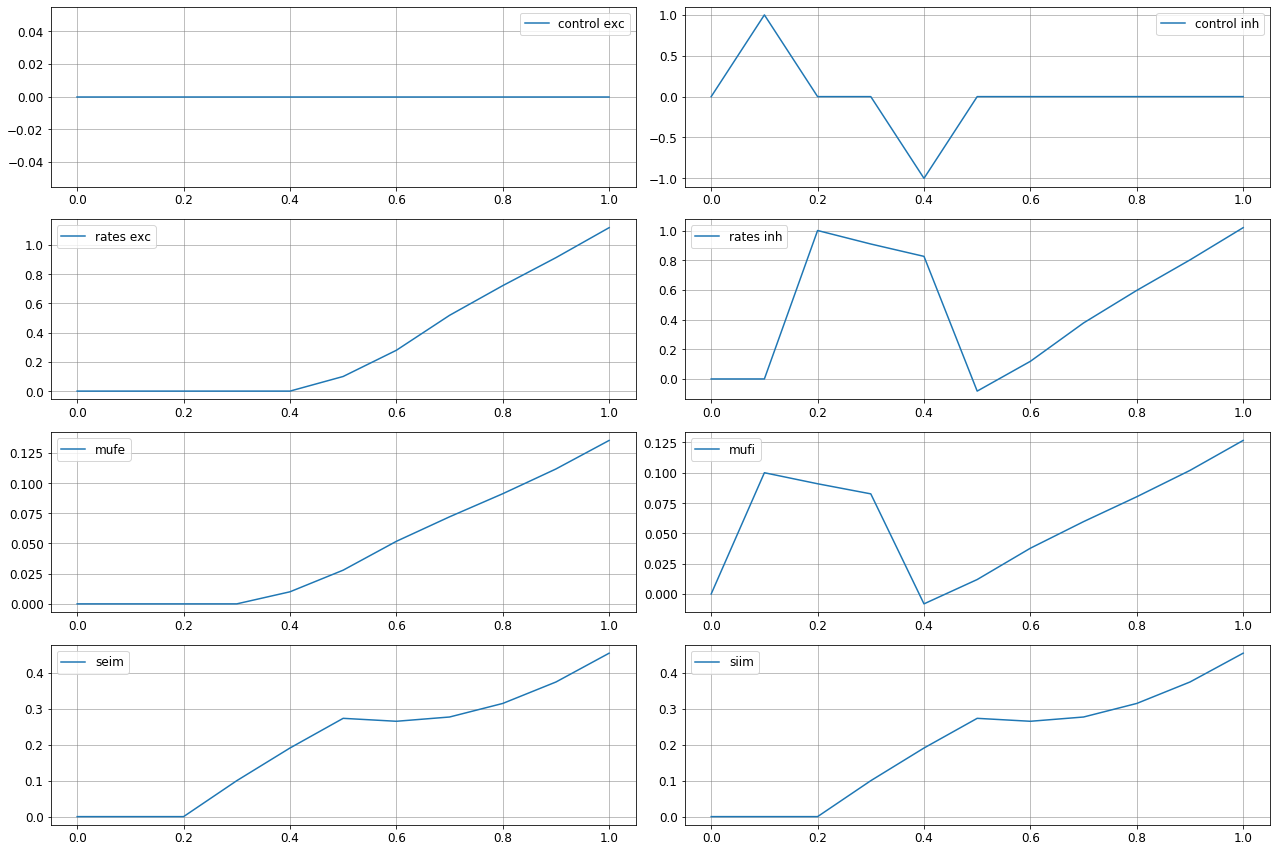

In [9]:
setparams()

dur = 1.
aln.params.duration = dur

target = aln.getZeroTarget()
control1 = aln.getZeroControl()

set_init(initvars)

#control1[0,0,1] += 100.
#control1[0,0,:] += np.sin(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

control1[0,1,1] += 1.
control1[0,1,4] -= 1.
#control1[0,1,:] += np.cos(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

aln.run(control=control1)

target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

plot_fig(0)
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])

[ 0.      0.      1.      0.9091  0.8258 -0.1742 -0.1565 -0.039   0.1566
  0.4104  0.617 ]


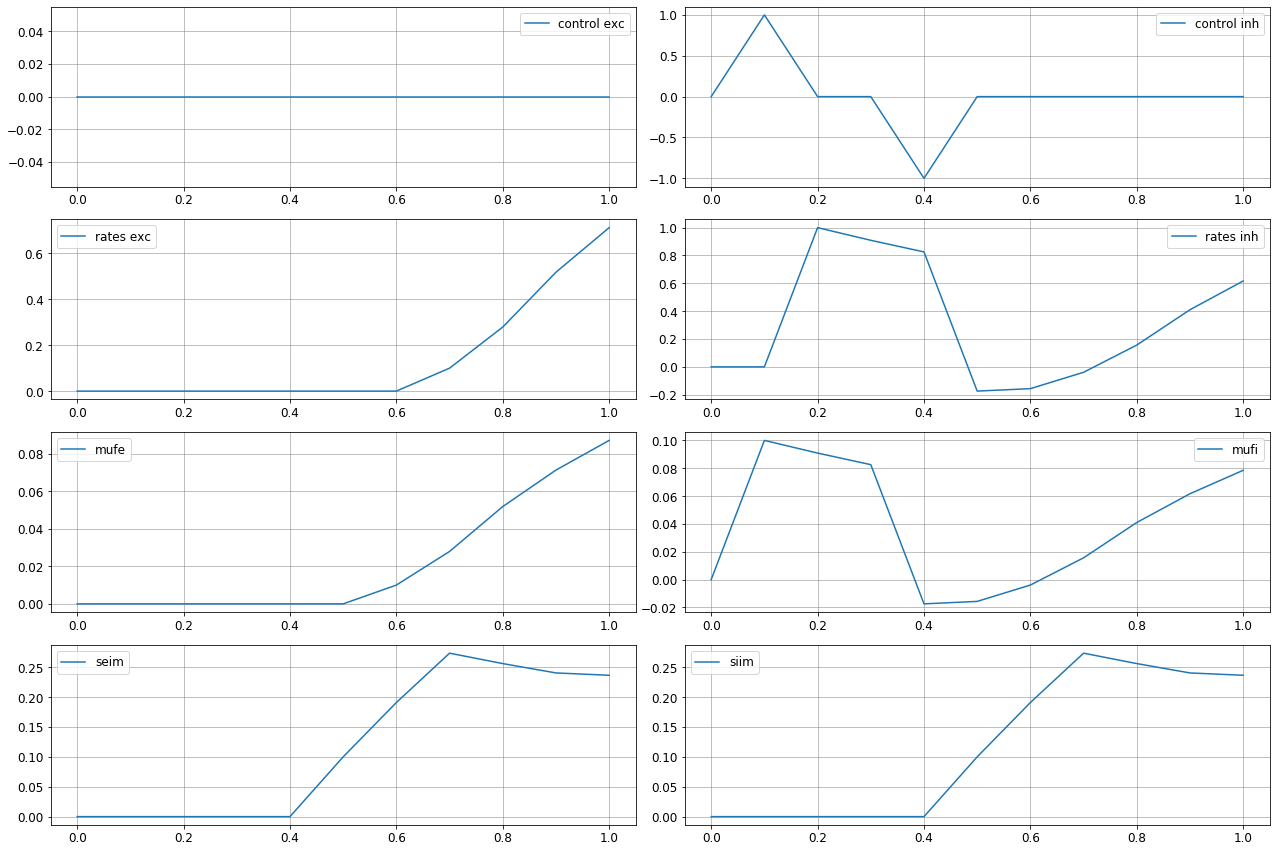

In [10]:
aln.params.di = 0.2
aln.run(control=control1)

plot_fig(0)
target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]
print(aln.state["rates_inh"][0,:])

In [12]:
max_cntrl = 50. * 5.
start_step = 100.
cost_params = [1.0, 0.0, 0.0]

#aln.params.di = 0.0

cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = aln.getZeroControl()
control2[0,1,1] += 1.01
control2[0,1,4] -= 1.01

max_it = 10
set_init(initvars)

A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

err = False
for c in range(len(A1_cost)-1):
    if A1_cost[c] < A1_cost[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")
    
#print(grad)

set cost params
....!
False 0
RUN  0 , total integrated cost =  2.0666819404538835e-05
RUN  1 , total integrated cost =  1.029437952071693e-05
RUN  2 , total integrated cost =  6.087185750249907e-06
RUN  3 , total integrated cost =  4.386547557666762e-06
RUN  4 , total integrated cost =  3.927682498228329e-06
RUN  5 , total integrated cost =  3.410064075091445e-06
RUN  6 , total integrated cost =  3.078362438658578e-06
RUN  7 , total integrated cost =  2.6367930879542456e-06
RUN  8 , total integrated cost =  2.3277896474822525e-06
RUN  9 , total integrated cost =  1.8042570821525792e-06
RUN  10 , total integrated cost =  1.5129501150776993e-06
Improved over  10  iterations by  92.67932774045809  percent.
max value of final gradient at index =  (array([0, 0, 0, 0], dtype=int64), array([0, 0, 1, 1], dtype=int64), array([ 0, 10,  0, 10], dtype=int64)) 0.0
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([4], dtype=int64)) -0.0079362182388940

ValueError: too many values to unpack (expected 4)

[ 0.          0.          1.00008646  0.90894232  0.82594421 -0.17436469
 -0.1564485  -0.03903585  0.15656578  0.41041209  0.6169592 ]


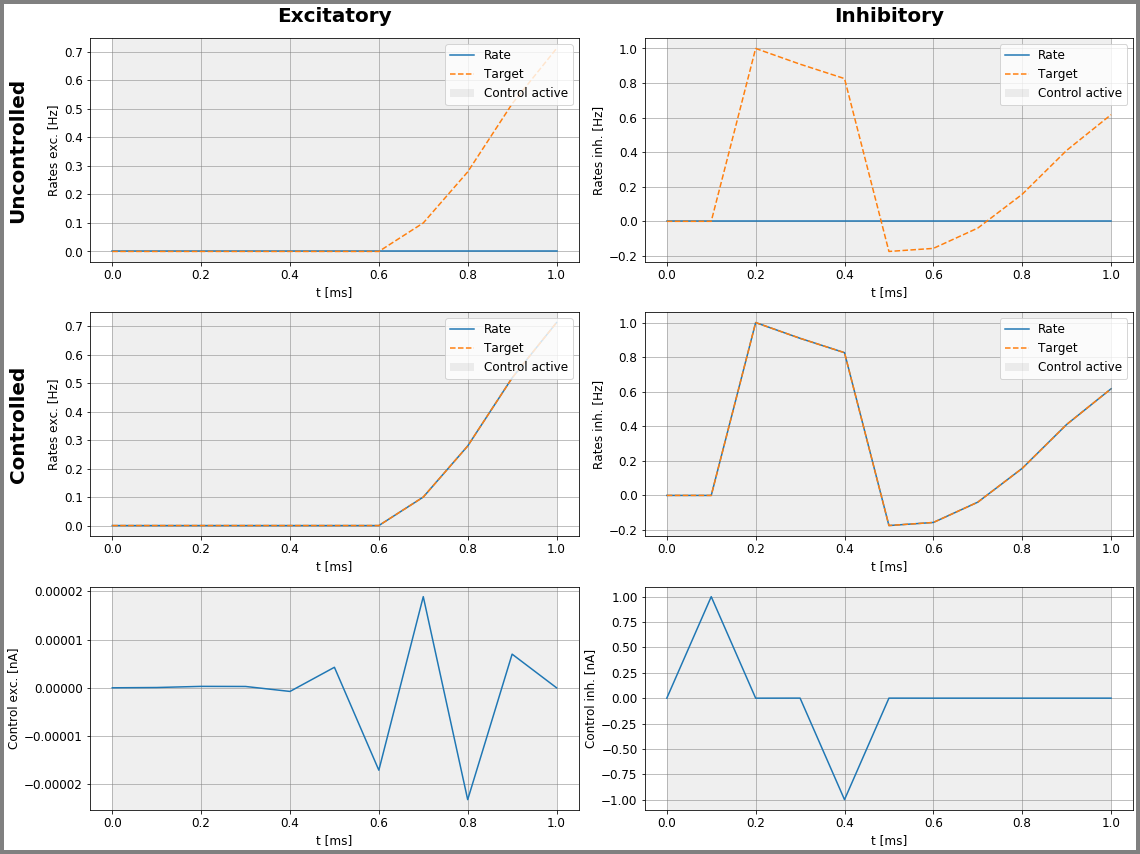

In [660]:
print(A1_bestState[0,1,:])
plotFunc.plot_control(aln, A1_bestControl, dur, dur_pre, dur_post, initvars, target,
                      path, filename_ = 'a1')

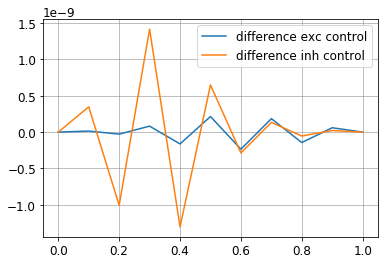

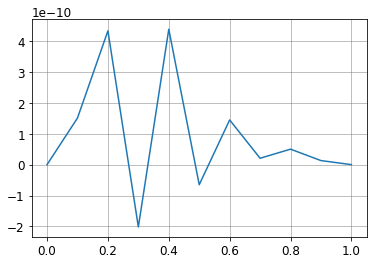

In [643]:
cDiff = control1 - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

plt.plot(aln.t, grad[0,1,:])
plt.show()

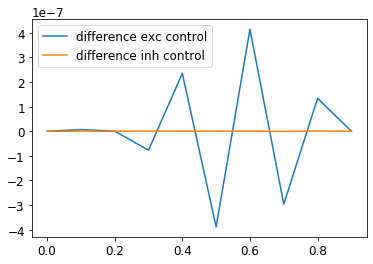

In [132]:
cDiff = control1 - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

In [85]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 30

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = aln.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  8.621233461195404
RUN  1 , total integrated cost:  1.733367747783146
RUN  2 , total integrated cost:  0.9917031181409316
RUN  3 , total integrated cost:  0.8015800251015909
RUN  4 , total integrated cost:  0.7366824551520769
RUN  5 , total integrated cost:  0.7125960110857322
RUN  6 , total integrated cost:  0.7029876961042139
RUN  7 , total integrated cost:  0.6998981952997376
change helped, counter =  1
change helped, counter =  2
change helped, counter =  1
RUN  8 , total integrated cost:  0.6989839644852788
RUN  9 , total integrated cost:  0.6987360982670723
RUN  10 , total integrated cost:  0.6986751141457996
RUN  11 , total integrated cost:  0.698661765119664
change helped, counter =  2
change helped, counter =  2
RUN  12 , total integrated cost:  0.6986594722674534
change helped, counter =  1
change helped, counter =  1
change helped, counter =  2
RUN  13 , total integrated cost:  0.698658937403531
change helped, counter =  2
chang

[[[ 0.          0.90516198  1.30021221  0.98171474  0.60662097
    0.        ]
  [ 0.          0.85815218  1.06740639 -0.08806821 -0.5889766
    0.        ]]]


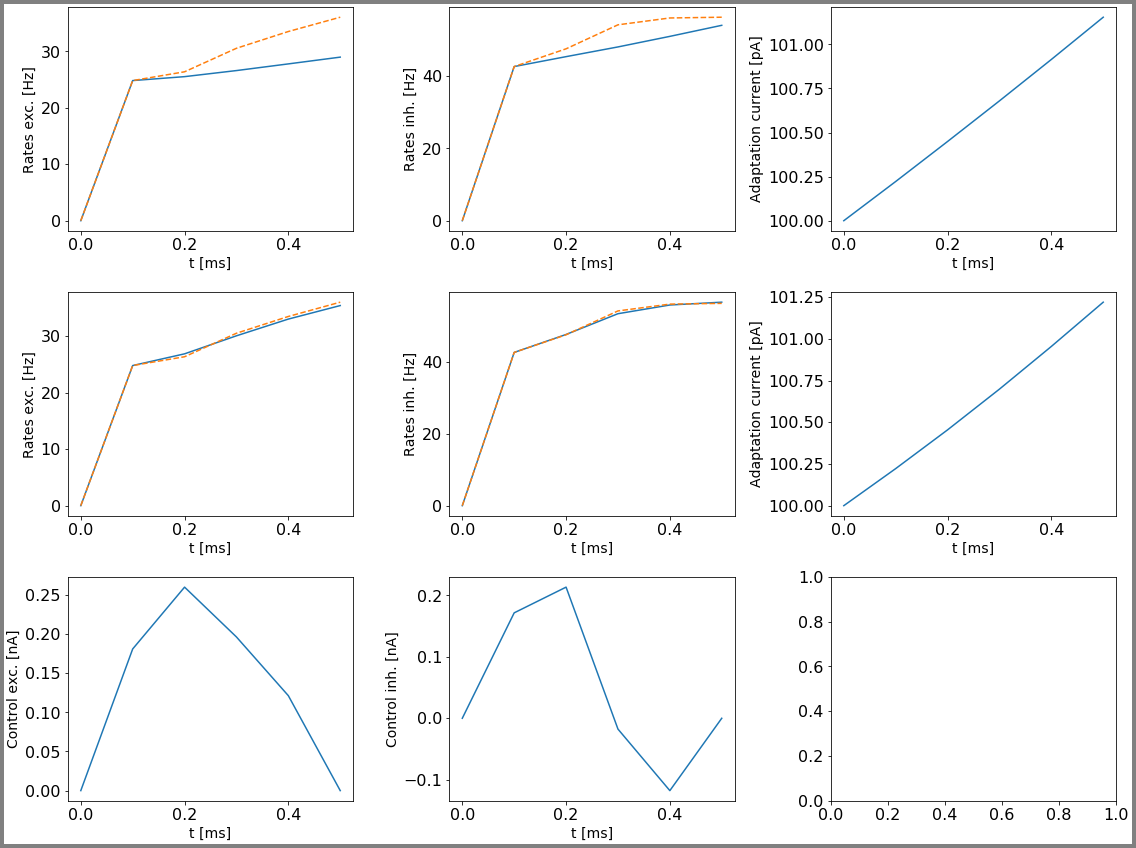

In [87]:
# 0.6986869710780511
print(A2_bestControlA)
plotFunc.plot_control(aln, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a1')

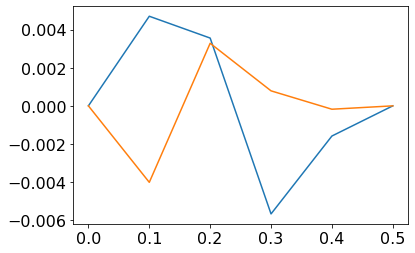

In [88]:
diff0 = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]
diff1 = A2_bestControlA[0,1,:] - A1_bestControlA[0,1,:]

plt.plot(aln.t, diff0)
plt.plot(aln.t, diff1)
plt.show()